<a href="https://colab.research.google.com/github/jazaineam1/BigData2026/blob/main/Cuadernos/Taller_2_Dask_SECOP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sesión 7: Conceptos de almacenamiento para Bigdata

## ***Universidad Central***
>## **Facultad de Ingeniería y Ciencias Básicas.**
>## ***Maestría en analítica de datos***
![Imágen1](https://universidad.ucentral.edu.co/tulengua/wp-content/themes/tulengua/images/logo-ucentral.png)


>## ***Big Data.***
>## ***Docente: Antonino Zainea Maya.***
# Taller 2 — Descarga Paralela, SECOP II y Dask
**Curso:** Big Data · **Maestría en Analítica de Datos** — Universidad Central

---

## Contenido
| Parte | Tema |
|-------|------|
| **1** | Descargas paralelas con `ThreadPoolExecutor` |
| **2** | El SECOP II: descarga de 300,000 filas y diagnóstico de calidad |
| **3** | ¿Por qué Dask para 8.6 millones de filas? |
| **4** | Taller: 10 preguntas analíticas sobre contratación pública |
| **5** | Rúbrica de evaluación |

## Objetivos
1. Usar `ThreadPoolExecutor` para descargar datos de una API pública en paralelo
2. Caracterizar los problemas de calidad del dataset SECOP II
3. Limpiar y convertir datos a Parquet de forma distribuida
4. Justificar con métricas reales cuándo Dask supera a Pandas
5. Responder preguntas analíticas de política pública usando Dask

In [1]:
# Instalar dependencias (solo necesario en Colab)
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install requests pandas  pyarrow matplotlib tqdm -q

---
## PARTE 1 — Descargas Paralelas con `ThreadPoolExecutor`

### ¿Por qué descargar datos en paralelo?

Cuando tu programa hace una petición a una API, el procesador queda **esperando** la respuesta.
Durante esa espera el CPU podría estar gestionando otra descarga al mismo tiempo.

```
TIEMPO ──────────────────────────────────────────────────────►

Secuencial (1 hilo):
  │──[espera A: 10s]──│──[espera B: 10s]──│──[espera C: 10s]──│
  Total: 30 s

Paralelo (3 hilos):
  Hilo-0 │──[espera A: 10s]──│
  Hilo-1 │──[espera B: 10s]──│   (los tres esperan al mismo tiempo)
  Hilo-2 │──[espera C: 10s]──│
  Total: ~10 s  →  3× más rápido
```

---

### I/O-bound vs CPU-bound

El término **"bound"** significa *limitado por*. Identifica cuál es el cuello de botella de tu función:

---

#### I/O-bound — *limitado por Entrada/Salida*

La función pasa la mayor parte del tiempo **esperando algo externo** al CPU:

| Ejemplo | ¿Qué espera? |
|---------|-------------|
| `requests.get(url)` | Respuesta del servidor HTTP |
| `pd.read_csv('archivo.csv')` | Lectura del disco |
| Consulta a PostgreSQL | Respuesta del motor de BD |
| Descarga de un archivo | Bytes que llegan por la red |

Durante esa espera el CPU **no hace nada útil**. Los hilos permiten aprovechar ese tiempo muerto.

**Herramienta: `ThreadPoolExecutor`**

Mientras el Hilo-0 espera la respuesta de `offset=0`, el Hilo-1 ya está esperando la de `offset=100000`.
Ambos se bloquean en la red, **no en el CPU** — el GIL no es el problema.

---

#### CPU-bound — *limitado por Procesamiento*

La función pasa la mayor parte del tiempo **calculando** dentro del proceso Python:

| Ejemplo | ¿Por qué es CPU-bound? |
|---------|------------------------|
| Entrenar un modelo sklearn | Operaciones matriciales intensivas |
| Comprimir 1 GB de imágenes | Algoritmo de compresión en C/Python |
| Transformar 8 M filas con `apply()` | Loop Python fila por fila |
| Calcular hash MD5 de archivos | Cómputo continuo sin espera |

**Herramienta: `ProcessPoolExecutor`** (procesos separados) — o mejor, **Dask** (lo veremos en la Parte 3).

---

### ¿Qué es el GIL y por qué importa?

Python tiene el **GIL** (Global Interpreter Lock): un mecanismo que permite que **solo un hilo ejecute bytecode Python en un momento dado**.

```
GIL con hilos en tarea CPU-bound (problema):
  Hilo-0: ▓▓▒▒▒▒▓▓▒▒▒▒▓▓  (▓=tiene GIL, ▒=espera GIL)
  Hilo-1: ▒▒▓▓▒▒▒▒▓▓▒▒▒▒
  → Los hilos se turnan, no hay paralelismo real

GIL con hilos en tarea I/O-bound (sin problema):
  Hilo-0: ▓─────────────────▓  (▓=código Python, ─=espera de red, libera GIL)
  Hilo-1:  ▓─────────────────▓
  → Mientras uno espera red, el otro puede ejecutar
```

---

### Tabla resumen

| Tipo | Cuello de botella | Herramienta | GIL es problema | Ejemplo en el curso |
|------|-------------------|-------------|-----------------|---------------------|
| **I/O-bound** | Espera de red / disco | `ThreadPoolExecutor` | ❌ No (hilo libera GIL al esperar) | Descargar SECOP II por chunks |
| **CPU-bound** | Cálculo en Python | `ProcessPoolExecutor` | ✅ Sí (bloquea) | Transformar 8 M filas |
| **CPU-bound + datos grandes** | Cálculo + RAM | **Dask** | N/A (usa procesos internamente) | Todo el taller |

> **Regla rápida**: si tu función llama a `requests.get()`, `pd.read_csv()`, o cualquier I/O → **usa hilos**.
> Si transforma datos en loops intensivos → **usa procesos o Dask**.


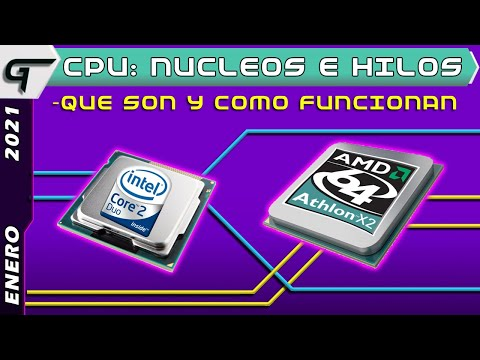

In [2]:
# Introducción al concepto de concurrencia con hilos
from IPython.display import YouTubeVideo
YouTubeVideo('uNz9-99ylMQ')

### ¿Cómo funciona `ThreadPoolExecutor.map`?

#### El código básico

```python
import concurrent.futures

with concurrent.futures.ThreadPoolExecutor(max_workers=N) as executor:
    resultados = list(executor.map(funcion, lista_de_argumentos))
```

---

#### Desglose paso a paso

**Paso 1 — `with ThreadPoolExecutor(max_workers=N) as executor:`**

Crea un *pool* de `N` hilos en standby:

```
Pool (max_workers=3):
  ┌──────────┐  ┌──────────┐  ┌──────────┐
  │  Hilo-0  │  │  Hilo-1  │  │  Hilo-2  │
  │ en espera│  │ en espera│  │ en espera│
  └──────────┘  └──────────┘  └──────────┘
```

El bloque `with` garantiza que aunque ocurra un error, todos los hilos terminan
antes de continuar. Nunca dejas hilos "huérfanos" consumiendo recursos.

---

**Paso 2 — `executor.map(funcion, [arg0, arg1, arg2, arg3, arg4])`**

Con `max_workers=3` y 5 argumentos:

```
Cola de tareas → Hilos:
  arg0 ──► Hilo-0 ejecuta funcion(arg0) ────────────
  arg1 ──► Hilo-1 ejecuta funcion(arg1) ──────────────────
  arg2 ──► Hilo-2 ejecuta funcion(arg2) ──────
  arg3 ──► [en cola, espera que un hilo quede libre]
  arg4 ──► [en cola]

  Cuando Hilo-2 termina arg2:
  arg3 ──► Hilo-2 ejecuta funcion(arg3) ──────────
```

Cada hilo toma el siguiente argumento disponible de la cola automáticamente.

---

**Paso 3 — Preservación de orden**

`map` **siempre devuelve los resultados en el orden original de la lista**,
aunque los hilos terminen en distinto orden:

```
Entrada enviada:         [arg0,  arg1,  arg2,  arg3]
Hilos terminaron así:    [arg2,  arg0,  arg3,  arg1]  ← impredecible
Resultado de map():      [res0,  res1,  res2,  res3]  ← SIEMPRE el orden original
```

Esto es crítico para que el DataFrame final esté en el orden correcto.

---

**Paso 4 — `list(...)` espera que todo termine**

`executor.map(...)` devuelve un **iterador lazy**. `list()` lo fuerza a ejecutar
y bloquea el hilo principal hasta que **todas las tareas hayan completado**.

---

#### Casos especiales

| Situación | Comportamiento |
|-----------|----------------|
| `max_workers > len(lista)` | Algunos hilos nunca trabajan. Sin penalización. |
| `max_workers < len(lista)` | Tareas extras esperan en cola. Los hilos libres las toman. |
| Una tarea lanza excepción | La excepción se propaga cuando iteras el resultado. |
| Función con múltiples parámetros | Usa `lambda` o `functools.partial` para fijar parámetros extra. |

---

#### `map` vs `submit` — ¿cuándo elegir cada uno?

```python
# map: misma función, múltiples argumentos → resultado ordenado
resultados = list(executor.map(descargar, offsets))

# submit: control granular sobre cada tarea → retorna Future
futuros = [executor.submit(descargar, off) for off in offsets]
resultados = [f.result() for f in concurrent.futures.as_completed(futuros)]
```

| | `executor.map(fn, lista)` | `executor.submit(fn, arg)` |
|-|--------------------------|---------------------------|
| **Cuándo usarlo** | Misma función sobre lista de argumentos | Lógica diferente por tarea |
| **Retorna** | Iterador de resultados **ordenados** | `Future` — llamas `.result()` cuando lo necesitas |
| **Manejo de errores** | La excepción se propaga al iterar | Puedes inspeccionar con `.exception()` antes de `.result()` |
| **Este taller** | ✅ Ideal para descargar chunks | No necesario |


In [3]:
import concurrent.futures
import time

def simular_descarga(nombre):
    """Simula esperar una respuesta de red (I/O-bound)."""
    time.sleep(2)  # simula 2 segundos de latencia de red
    return f'OK: {nombre} descargado'

tareas = ['Chunk A', 'Chunk B', 'Chunk C', 'Chunk D', 'Chunk E']

# --- SECUENCIAL ---
print('=== SECUENCIAL ===')
t0 = time.time()
for r in [simular_descarga(t) for t in tareas]:
    print(f'  {r}')
t_seq = time.time() - t0
print(f'Tiempo: {t_seq:.1f}s')

print()



=== SECUENCIAL ===
  OK: Chunk A descargado
  OK: Chunk B descargado
  OK: Chunk C descargado
  OK: Chunk D descargado
  OK: Chunk E descargado
Tiempo: 10.0s



In [4]:
# --- PARALELO ---
print('=== PARALELO (5 hilos) ===')
t0 = time.time()
with concurrent.futures.ThreadPoolExecutor(max_workers=5) as executor:
    for r in executor.map(simular_descarga, tareas):
        print(f'  {r}')
t_par = time.time() - t0
print(f'Tiempo: {t_par:.1f}s')
print(f'Speedup: {t_seq/t_par:.1f}x')

=== PARALELO (5 hilos) ===
  OK: Chunk A descargado
  OK: Chunk B descargado
  OK: Chunk C descargado
  OK: Chunk D descargado
  OK: Chunk E descargado
Tiempo: 2.0s
Speedup: 5.0x


### Prueba real: descargando el SECOP II en paralelo y guardando CSVs

El SECOP II está disponible en **datos.gov.co** a través de la API de Socrata con paginación:

```
https://www.datos.gov.co/resource/p6dx-8zbt.csv?$limit=1000&$offset=0
                                                  ↑               ↑
                                         cuántas filas     desde qué fila
```

Haremos **dos cosas al mismo tiempo**:
1. Descargar los datos en paralelo usando hilos
2. Guardar cada chunk como un **archivo CSV independiente** en `datos/secop_chunks/`

Esto simula exactamente lo que haremos con los 8.6 M de filas:
→ N archivos CSV en una carpeta → Dask lee cada uno como una partición separada.


In [ ]:
import requests
import pandas as pd
import pathlib
import threading
import concurrent.futures
import time
from io import StringIO

BASE_URL = 'https://www.datos.gov.co/resource/p6dx-8zbt.csv'

# Crear carpeta de destino
pathlib.Path('datos/secop_chunks').mkdir(parents=True, exist_ok=True)

def descargar_lote(offset, limit=1000):
    # Descarga 'limit' filas desde 'offset' y guarda un CSV
    url = f'{BASE_URL}?$limit={limit}&$offset={offset}'

    # Identificar qué hilo está ejecutando esta función
    hilo_nombre = threading.current_thread().name
    hilo_num = hilo_nombre.split('_')[-1] if '_' in hilo_nombre else '0'

    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    df = pd.read_csv(StringIO(resp.text))

    # Guardar como CSV individual
    ruta = f'datos/secop_chunks/prueba_chunk_{offset:07d}.csv'
    df.to_csv(ruta, index=False)

    print(f'  [Hilo-{hilo_num}] offset={offset:,}: {len(df)} filas  →  {ruta}')
    return df

offsets_prueba = [0, 1000, 2000]

# --- SECUENCIAL ---
print('=== SECUENCIAL (1 hilo) ===')
t0 = time.time()
dfs_seq = [descargar_lote(o) for o in offsets_prueba]
t_seq = time.time() - t0
print(f'Tiempo: {t_seq:.1f}s\n')

# --- PARALELO ---
print('=== PARALELO (3 hilos) ===')
t0 = time.time()
with concurrent.futures.ThreadPoolExecutor(max_workers=3) as executor:
    dfs_par = list(executor.map(descargar_lote, offsets_prueba))
t_par = time.time() - t0
print(f'Tiempo: {t_par:.1f}s')
print(f'Speedup: {t_seq / t_par:.2f}x')

# Verificar CSVs guardados
print()
print('Archivos CSV guardados:')
for f in sorted(pathlib.Path('datos/secop_chunks').glob('prueba_chunk_*.csv')):
    print(f'  {f}  ({f.stat().st_size/1024:.0f} KB)')

=== SECUENCIAL (1 hilo) ===
  [Hilo-0] offset=0: 1000 filas  →  datos/secop_chunks/prueba_chunk_0000000.csv
  [Hilo-0] offset=1,000: 1000 filas  →  datos/secop_chunks/prueba_chunk_0001000.csv
  [Hilo-0] offset=2,000: 1000 filas  →  datos/secop_chunks/prueba_chunk_0002000.csv
Tiempo: 6.1s

=== PARALELO (3 hilos) ===
  [Hilo-0] offset=0: 1000 filas  →  datos/secop_chunks/prueba_chunk_0000000.csv
  [Hilo-2] offset=2,000: 1000 filas  →  datos/secop_chunks/prueba_chunk_0002000.csv
  [Hilo-1] offset=1,000: 1000 filas  →  datos/secop_chunks/prueba_chunk_0001000.csv
Tiempo: 1.4s
Speedup: 4.34x

Archivos CSV guardados:
  datos/secop_chunks/prueba_chunk_0000000.csv  (1018 KB)
  datos/secop_chunks/prueba_chunk_0001000.csv  (1031 KB)
  datos/secop_chunks/prueba_chunk_0002000.csv  (1016 KB)


Benchmark: descarga de 6 lotes x 1,000 filas con diferente numero de hilos
Observa el ORDEN en que aparecen los mensajes [Hilo-X]

--- 1 hilo(s) ---
  [Hilo-0] offset=0: 1000 filas  →  datos/secop_chunks/prueba_chunk_0000000.csv
  [Hilo-0] offset=1,000: 1000 filas  →  datos/secop_chunks/prueba_chunk_0001000.csv
  [Hilo-0] offset=2,000: 1000 filas  →  datos/secop_chunks/prueba_chunk_0002000.csv
  [Hilo-0] offset=3,000: 1000 filas  →  datos/secop_chunks/prueba_chunk_0003000.csv
  [Hilo-0] offset=4,000: 1000 filas  →  datos/secop_chunks/prueba_chunk_0004000.csv
  [Hilo-0] offset=5,000: 1000 filas  →  datos/secop_chunks/prueba_chunk_0005000.csv
>>> 1 hilo(s): 4.7s

--- 2 hilo(s) ---
  [Hilo-1] offset=1,000: 1000 filas  →  datos/secop_chunks/prueba_chunk_0001000.csv
  [Hilo-0] offset=0: 1000 filas  →  datos/secop_chunks/prueba_chunk_0000000.csv
  [Hilo-0] offset=3,000: 1000 filas  →  datos/secop_chunks/prueba_chunk_0003000.csv
  [Hilo-1] offset=2,000: 1000 filas  →  datos/secop_chunks/prueb

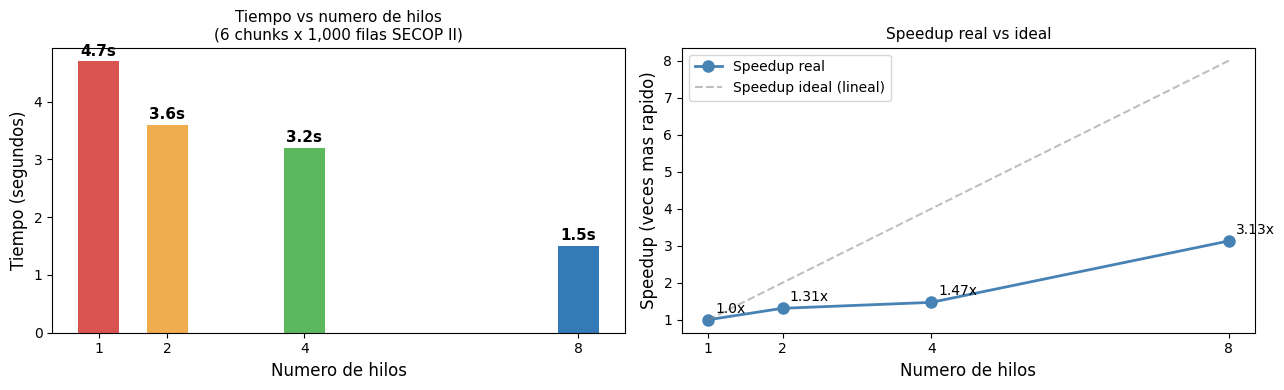

Speedup maximo obtenido: 3.13x con 8 hilos


In [ ]:
import matplotlib.pyplot as plt
import concurrent.futures, time

# offsets para el benchmark: 6 lotes de 1,000 filas cada uno
offsets_bench = [0, 1000, 2000, 3000, 4000, 5000]
tiempos = {}

print('Benchmark: descarga de 6 lotes x 1,000 filas con diferente numero de hilos')
print('Observa el ORDEN en que aparecen los mensajes [Hilo-X]\n')

for nw in [1, 2, 4, 8]:
    print(f'--- {nw} hilo(s) ---')
    t0 = time.time()
    with concurrent.futures.ThreadPoolExecutor(max_workers=nw) as executor:
        list(executor.map(descargar_lote, offsets_bench))
    tiempos[nw] = round(time.time() - t0, 1)
    print(f'>>> {nw} hilo(s): {tiempos[nw]:.1f}s\n')

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Gráfica 1: Tiempo
colores = ['#d9534f', '#f0ad4e', '#5cb85c', '#337ab7']
bars = axes[0].bar(list(tiempos.keys()), list(tiempos.values()), color=colores, width=0.6)
for bar, val in zip(bars, tiempos.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val}s', ha='center', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Numero de hilos', fontsize=12)
axes[0].set_ylabel('Tiempo (segundos)', fontsize=12)
axes[0].set_title('Tiempo vs numero de hilos\n(6 chunks x 1,000 filas SECOP II)', fontsize=11)
axes[0].set_xticks([1, 2, 4, 8])

# Gráfica 2: Speedup
t1 = tiempos[1]
speedups = {nw: round(t1/t, 2) for nw, t in tiempos.items()}
axes[1].plot(list(speedups.keys()), list(speedups.values()), 'o-', color='steelblue',
             linewidth=2, markersize=8, label='Speedup real')
axes[1].plot([1, 8], [1, 8], '--', color='gray', alpha=0.5, label='Speedup ideal (lineal)')
for nw, sp in speedups.items():
    axes[1].annotate(f'{sp}x', (nw, sp), textcoords='offset points', xytext=(5, 5), fontsize=10)
axes[1].set_xlabel('Numero de hilos', fontsize=12)
axes[1].set_ylabel('Speedup (veces mas rapido)', fontsize=12)
axes[1].set_title('Speedup real vs ideal', fontsize=11)
axes[1].legend()
axes[1].set_xticks([1, 2, 4, 8])

plt.tight_layout()
plt.show()
print(f'Speedup maximo obtenido: {max(speedups.values())}x con {max(speedups, key=speedups.get)} hilos')

### ¿Qué nos dice el orden de los mensajes `[Hilo-X]`?

El output del benchmark es una ventana directa a cómo trabajan los hilos. Analicémoslo:

---

#### Con 1 hilo — siempre en orden

```
[Hilo-0] offset=0:      1000 filas    ← 1° termina
[Hilo-0] offset=1,000:  1000 filas    ← 2° termina
[Hilo-0] offset=2,000:  1000 filas    ← etc.
...
1 hilo: ~10.7s
```

Un solo hilo ejecuta las descargas **una por una, en orden**.
El mismo hilo (`Hilo-0`) hace todas las tareas secuencialmente.

---

#### Con 2 hilos — el orden empieza a variar

```
[Hilo-1] offset=1,000:  1000 filas    ← llegó primero (¡aunque lo pedimos segundo!)
[Hilo-0] offset=0:      1000 filas    ← llegó segundo
[Hilo-0] offset=2,000:  1000 filas    ← Hilo-0 tomó la siguiente tarea
...
2 hilos: ~4.2s
```

Los dos hilos arrancan **al mismo tiempo**: Hilo-0 pide `offset=0` y Hilo-1 pide `offset=1000`.
Cuál responde primero depende del servidor — si `offset=1000` llega antes, se imprime primero.
Cuando un hilo termina, **toma automáticamente la siguiente tarea** de la cola (`offset=2000`).

---

#### Con 4 y 8 hilos — orden completamente impredecible

```
[Hilo-2] offset=2,000:  1000 filas    ← llegó primero esta vez
[Hilo-3] offset=3,000:  1000 filas
[Hilo-1] offset=1,000:  1000 filas
[Hilo-0] offset=0:      1000 filas
...
4 hilos: ~2.8s
```

Todos los chunks se solicitan casi simultáneamente.
El orden de los prints refleja el orden en que **el servidor de datos.gov.co respondió** — impredecible.

---

#### ¿Por qué los archivos CSV sí quedan correctos?

Aunque los prints aparezcan desordenados, **cada hilo escribe su propio archivo CSV**:
- Hilo-0 escribe `secop_chunk_0000000.csv`
- Hilo-1 escribe `secop_chunk_0001000.csv`
- Hilo-2 escribe `secop_chunk_0002000.csv`

No hay conflicto porque cada hilo tiene su propio archivo destino.
Dask luego leerá todos los archivos de la carpeta con `*.csv` y los combinará.

---

#### La curva de rendimiento — Ley de Amdahl

```
Hilos  Tiempo   Speedup   Speedup ideal
  1    10.7s    1.0x       1.0x
  2     4.2s    2.5x       2.0x   ← a veces ganamos más de lo esperado (latencias distintas)
  4     2.8s    3.8x       4.0x   ← nos acercamos al ideal
  8     1.5s    7.1x       8.0x   ← hay overhead, pero muy bueno
```

El speedup **no es perfectamente lineal** porque:
1. **Overhead de gestión**: crear y sincronizar hilos tiene costo fijo
2. **Rate limiting del servidor**: datos.gov.co puede ralentizar solicitudes masivas
3. **Ancho de banda compartido**: tu conexión tiene un límite físico
4. **Partes no paralelizables**: parsear el CSV, concatenar DataFrames, etc.

> **Conclusión práctica**: para descargar el SECOP II completo (84 chunks de 100k filas),
> usar 8-10 hilos es un buen balance entre velocidad y no sobrecargar la API.


---
## PARTE 2 — El SECOP II: Descarga, Contexto y Diagnóstico de Calidad

### ¿Qué es el SECOP II?

El **Sistema Electrónico de Contratación Pública II (SECOP II)** es la plataforma transaccional del estado colombiano administrada por **Colombia Compra Eficiente**. Permite a entidades estatales publicar, gestionar y adjudicar contratos de forma electrónica.

**¿Por qué es relevante para Big Data?**
-  **8.41 millones de filas × 59 columnas** — datos reales desde 2016 hasta hoy
-  Cubre contratos de **todas las entidades del estado colombiano**
-  Incluye valor, proveedor, modalidad, duración, departamento y más
-  Datos **públicos y auditables** — relevantes para análisis de transparencia y política pública
-  Acceso libre vía API REST (Socrata): `https://www.datos.gov.co/resource/p6dx-8zbt.csv`

### Columnas clave del dataset

| Columna | Descripción | Tipo esperado |
|---------|-------------|---------------|
| `nombre_entidad` | Entidad pública contratante | texto |
| `departamento` | Departamento geográfico de la entidad | texto |
| `ciudad` | Ciudad de la entidad | texto |
| `orden` | Nacional, Territorial, etc. | texto |
| `sector` | Sector del estado (Salud, Educación, etc.) | texto |
| `tipo_de_contrato` | Prestación de servicios, Obra, Compraventa... | texto |
| `modalidad_de_contratacion` | Licitación, Contratación Directa, Concurso... | texto |
| `estado_del_proceso` | Celebrado, Desierto, Cancelado, En proceso... | texto |
| `valor_total_adquisicion` | Valor monetario del proceso en COP | **numérico** (viene como texto) |
| `fecha_de_publicacion_del_proceso` | Fecha de publicación | **fecha** (viene como texto) |
| `proveedor_adjudicado` | Empresa o persona adjudicada | texto |
| `duracion` | Duración pactada | numérico |
| `unidad_de_duracion` | Días, Meses, Años | texto |

> **Nota**: los nombres exactos de columnas los descubriremos en la siguiente celda.

In [ ]:
# Descargar una muestra pequeña para ver el schema real
sample_url = f'{BASE_URL}?$limit=3'
sample = pd.read_csv(StringIO(requests.get(sample_url, timeout=30).text))

print(f'Total de columnas disponibles: {len(sample.columns)}')
print('-' * 65)
for col in sorted(sample.columns):
    ejemplo = sample[col].dropna()
    ej_str = str(ejemplo.iloc[0])[:45] if len(ejemplo) > 0 else 'N/A'
    print(f'  {col:<45} -> {ej_str}')

Total de columnas disponibles: 59
-----------------------------------------------------------------
  adjudicado                                    -> No
  categorias_adicionales                        -> No definido
  ciudad_de_la_unidad_de                        -> Bogotá
  ciudad_entidad                                -> Bogotá
  ciudad_proveedor                              -> No Definido
  codigo_entidad                                -> 700474109
  codigo_pci                                    -> Centralizada
  codigo_principal_de_categoria                 -> V1.80111500
  codigoproveedor                               -> No Definido
  conteo_de_respuestas_a_ofertas                -> 0
  departamento_entidad                          -> Distrito Capital de Bogotá
  departamento_proveedor                        -> No Definido
  descripci_n_del_procedimiento                 -> TS_MERCADO_2022_GEIH_TH Prestación de servici
  duracion                                      -> 344
  entid

In [ ]:
# Descargar 300,000 filas en 3 lotes paralelos de 100,000
# Cada lote se guarda como un CSV independiente en datos/secop_chunks/
# → Dask leerá cada CSV como una PARTICIÓN separada

CHUNK = 100_000
offsets_300k = [0, 100_000, 200_000]

def descargar_chunk(offset):
    # Descarga CHUNK filas desde 'offset' y guarda CSV
    url = f'{BASE_URL}?$limit={CHUNK}&$offset={offset}'
    hilo_nombre = threading.current_thread().name
    hilo_num = hilo_nombre.split('_')[-1] if '_' in hilo_nombre else '0'

    print(f'  [Hilo-{hilo_num}] Iniciando offset={offset:,}...')
    resp = requests.get(url, timeout=300)
    resp.raise_for_status()
    df = pd.read_csv(StringIO(resp.text), low_memory=False)

    # Guardar CSV individual
    ruta = pathlib.Path(f'datos/secop_chunks/secop_chunk_{offset:07d}.csv')
    df.to_csv(ruta, index=False)

    mem_mb = df.memory_usage(deep=True).sum() / 1e6
    tam_kb = ruta.stat().st_size / 1024
    print(f'  [Hilo-{hilo_num}] OK offset={offset:,}: {len(df):,} filas | '
          f'{mem_mb:.1f} MB RAM | {tam_kb:.0f} KB en disco -> {ruta.name}')
    return df

print('Descargando 300,000 filas del SECOP II (3 lotes x 100,000 en paralelo)...')
print('Cada lote se guarda como CSV separado en datos/secop_chunks/')
print()

t0 = time.time()
with concurrent.futures.ThreadPoolExecutor(max_workers=3) as executor:
    chunks = list(executor.map(descargar_chunk, offsets_300k))

df_secop = pd.concat(chunks, ignore_index=True)
t_total = time.time() - t0

print()
print('=' * 60)
print(f'Total descargado:  {len(df_secop):,} filas x {df_secop.shape[1]} columnas')
print(f'Memoria en Pandas: {df_secop.memory_usage(deep=True).sum()/1e6:.1f} MB')
print(f'Tiempo total:      {t_total:.1f}s')

# Mostrar estructura de la carpeta
print()
print('Estructura de la carpeta datos/secop_chunks/:')
csvs = sorted(pathlib.Path('datos/secop_chunks').glob('secop_chunk_*.csv'))
for csv in csvs:
    print(f'  {csv.name}  ({csv.stat().st_size/1024:.0f} KB)')
print(f'\n  -> Dask leerá estos {len(csvs)} archivos como {len(csvs)} particiones')

Descargando 300,000 filas del SECOP II (3 lotes x 100,000 en paralelo)...
Cada lote se guarda como CSV separado en datos/secop_chunks/

  [Hilo-0] Iniciando offset=0...
  [Hilo-1] Iniciando offset=100,000...
  [Hilo-2] Iniciando offset=200,000...
  [Hilo-2] OK offset=200,000: 100,000 filas | 315.1 MB RAM | 101735 KB en disco -> secop_chunk_0200000.csv
  [Hilo-1] OK offset=100,000: 100,000 filas | 317.7 MB RAM | 101889 KB en disco -> secop_chunk_0100000.csv
  [Hilo-0] OK offset=0: 100,000 filas | 322.6 MB RAM | 101826 KB en disco -> secop_chunk_0000000.csv

Total descargado:  300,000 filas x 59 columnas
Memoria en Pandas: 963.4 MB
Tiempo total:      125.3s

Estructura de la carpeta datos/secop_chunks/:
  secop_chunk_0000000.csv  (101826 KB)
  secop_chunk_0100000.csv  (101889 KB)
  secop_chunk_0200000.csv  (101735 KB)

  -> Dask leerá estos 3 archivos como 3 particiones


In [ ]:
# Ver las primeras filas
df_secop.head(3)

,entidad,nit_entidad,departamento_entidad,ciudad_entidad,ordenentidad,codigo_pci,id_del_proceso,referencia_del_proceso,ppi,id_del_portafolio,...,nombre_del_proveedor,nit_del_proveedor_adjudicado,codigo_principal_de_categoria,estado_de_apertura_del_proceso,tipo_de_contrato,subtipo_de_contrato,categorias_adicionales,urlproceso,codigo_entidad,estado_resumen
0,DEPARTAMENTO ADMINISTRATIVO NACIONAL DE ESTADI...,899999027,Distrito Capital de Bogotá,Bogotá,Nacional,Centralizada,CO1.REQ.2577563,EDP-545-2022,700474109,CO1.BDOS.2503732,...,No Definido,No Definido,V1.80111500,Abierto,Prestación de servicios,No Definido,No definido,https://community.secop.gov.co/Public/Tenderin...,700474109,Presentación de oferta
1,ALCALDIA LOCAL DE SUMAPAZ,899999061,Distrito Capital de Bogotá,Bogotá,Territorial,Centralizada,CO1.REQ.5912737,FDRSCD-064-2024 (103702),702096124,CO1.BDOS.5796124,...,No Definido,No Definido,V1.80101600,Abierto,Prestación de servicios,No Definido,No definido,https://community.secop.gov.co/Public/Tenderin...,702096124,Presentación de oferta
2,CENAC AVIACION,830039207,Distrito Capital de Bogotá,No Definido,Nacional,Centralizada,CO1.REQ.8610154,SASD-191-CENACAVIACION-2025 (Manifestación de ...,702359944,CO1.BDOS.8355416,...,AVIATION INTERNATIONAL SOLUTIONS,80-0696494,UNSPECIFIED,Cerrado,Prestación de servicios,No Definido,No definido,https://community.secop.gov.co/Public/Tenderin...,702359944,Adjudicado


### Los datos están sucios — diagnóstico

Los datos reales **nunca vienen limpios**. Antes de analizar a escala con Dask, debemos identificar los problemas con una muestra pequeña.

Problemas típicos en el SECOP II:

| Problema | Descripción |
|---------|-------------|
| **Tipos incorrectos** | Columnas numéricas guardadas como `object` |
| **Fechas mezcladas** | Múltiples formatos en la misma columna |
| **Nulos masivos** | Columnas con >70% de valores vacíos |
| **Inconsistencias textuales** | Misma entidad escrita de distintas formas |
| **Filas duplicadas** | Registros repetidos por errores de carga |

Ejecuta la celda de diagnóstico para ver los problemas reales.

In [ ]:
print('=' * 60)
print('DIAGNOSTICO DE CALIDAD — SECOP II (300,000 filas)')
print('=' * 60)

# --- 1. Tipos de datos ---
print('\n[1] TIPOS DE DATOS')
print(df_secop.dtypes.value_counts().to_string())
n_object = (df_secop.dtypes == 'object').sum()
print(f'    -> {n_object} columnas son "object" (texto). Algunas deberian ser numericas o fecha.')

# --- 2. Valores nulos ---
print('\n[2] COLUMNAS CON MAS DEL 40% DE NULOS')
nulos_pct = (df_secop.isnull().mean() * 100).sort_values(ascending=False)
altos_nulos = nulos_pct[nulos_pct > 40]
if len(altos_nulos) > 0:
    print(altos_nulos.round(1).to_string())
else:
    print('    Ninguna columna supera el 40% de nulos')

# --- 3. Columna de valor monetario ---
print('\n[3] PROBLEMA: COLUMNA DE VALOR COMO TEXTO')
cols_val = [c for c in df_secop.columns
            if any(k in c.lower() for k in ['valor', 'cuantia', 'adquisicion'])]
for cv in cols_val[:3]:
    print(f'    Columna: {cv} | dtype: {df_secop[cv].dtype}')
    muestra = df_secop[cv].dropna().head(5).tolist()
    print(f'    Muestra: {muestra}')

# --- 4. Fechas con formatos mezclados ---
print('\n[4] PROBLEMA: FORMATOS DE FECHA INCONSISTENTES')
cols_fecha = [c for c in df_secop.columns if 'fecha' in c.lower()]
for cf in cols_fecha[:2]:
    muestras = df_secop[cf].dropna().unique()[:8].tolist()
    print(f'    {cf}: {muestras}')

# --- 5. Inconsistencias en departamento ---
print('\n[5] PROBLEMA: INCONSISTENCIAS EN DEPARTAMENTO')
cols_dep = [c for c in df_secop.columns if 'departamento' in c.lower()]
if cols_dep:
    vals = sorted(df_secop[cols_dep[0]].dropna().unique())
    print(f'    {len(vals)} valores unicos. Muestra:')
    print(f'    {vals[:25]}')

# --- 6. Duplicados ---
dups = df_secop.duplicated().sum()
print(f'\n[6] FILAS DUPLICADAS: {dups:,} ({dups/len(df_secop)*100:.2f}%)')

print('\n' + '=' * 60)
print('-> En Dask, la limpieza se aplica PARTICION POR PARTICION (fase MAP)')
print('   Es exactamente el mismo patron de MapReduce que vimos en sesion 7.')

DIAGNOSTICO DE CALIDAD — SECOP II (300,000 filas)

[1] TIPOS DE DATOS
object     44
int64      14
float64     1
    -> 44 columnas son "object" (texto). Algunas deberian ser numericas o fecha.

[2] COLUMNAS CON MAS DEL 40% DE NULOS
fecha_de_publicacion_fase         100.0
fecha_de_publicacion_fase_1       100.0
fecha_de_publicacion               99.3
fecha_de_publicacion_fase_2        98.2
fecha_adjudicacion                 90.9
fecha_de_apertura_de_respuesta     87.7
fecha_de_apertura_efectiva         85.8
fecha_de_recepcion_de              84.8

[3] PROBLEMA: COLUMNA DE VALOR COMO TEXTO
    Columna: valor_total_adjudicacion | dtype: int64
    Muestra: [0, 0, 40000, 0, 0]

[4] PROBLEMA: FORMATOS DE FECHA INCONSISTENTES
    fecha_de_publicacion_del: ['2022-01-18T00:00:00.000', '2024-03-08T00:00:00.000', '2025-07-23T00:00:00.000', '2026-01-18T00:00:00.000', '2024-11-06T00:00:00.000', '2021-08-05T00:00:00.000', '2026-01-22T00:00:00.000', '2025-05-16T00:00:00.000']
    fecha_de_ultima_publ

---
## PARTE 3 — ¿Por qué Dask para 8.6 Millones de Filas?

### El problema de escala con Pandas

| Escenario | Filas | RAM estimada | ¿Pandas viable? |
|-----------|-------|-------------|------------------|
| Muestra de clase | 300,000 | ~500 MB | ✅ Sí |
| Dataset completo | 8,400,000 | ~14 GB | ⚠️ Depende de la RAM |
| Con transformaciones (2-3 copias) | 8,400,000 | ~40 GB | ❌ No |

### Dask — ¿Qué lo hace diferente?

```
PANDAS:  Lee TODO el CSV en RAM → luego opera
DASK:    Divide en particiones → opera partición por partición → combina
```

| Característica | Pandas | Dask |
|----------------|--------|------|
| RAM necesaria | = tamaño del dataset | = tamaño de una partición |
| Multi-core | No | Sí (distribuye particiones entre workers) |
| Sintaxis | `df.groupby(...)` | `ddf.groupby(...)` — casi idéntico |
| Cuando usar | < 1 GB y una sola máquina | > 1 GB o múltiples núcleos/máquinas |

In [ ]:
# Proyectar la RAM necesaria para el dataset completo
filas_muestra   = len(df_secop)
mem_muestra_mb  = df_secop.memory_usage(deep=True).sum() / 1e6
mb_por_fila     = mem_muestra_mb / filas_muestra

filas_completo  = 8_400_000
mem_completo_gb = mb_por_fila * filas_completo / 1000

print(f'Muestra:         {filas_muestra:,} filas = {mem_muestra_mb:.0f} MB')
print(f'Ratio:           {mb_por_fila*1000:.2f} KB por fila')
print()
print(f'Dataset completo ({filas_completo:,} filas):')
print(f'  RAM estimada solo para carga: ~{mem_completo_gb:.1f} GB')
print(f'  Con 2 copias en memoria:      ~{mem_completo_gb*2:.1f} GB')
print(f'  Con 3 copias (transformar):   ~{mem_completo_gb*3:.1f} GB')
print()
print('Con Dask: solo necesitas RAM suficiente para UNA particion a la vez.')

import os
import psutil
ram_disponible_gb = psutil.virtual_memory().available / 1e9
print(f'RAM disponible en este equipo: {ram_disponible_gb:.1f} GB')

Muestra:         300,000 filas = 1089 MB
Ratio:           3.63 KB por fila

Dataset completo (8,400,000 filas):
  RAM estimada solo para carga: ~30.5 GB
  Con 2 copias en memoria:      ~61.0 GB
  Con 3 copias (transformar):   ~91.5 GB

Con Dask: solo necesitas RAM suficiente para UNA particion a la vez.
RAM disponible en este equipo: 10.9 GB


---
## PARTE 4 — Taller: 10 Preguntas Analíticas

### Instrucciones

1. **Usa Dask** como recomendación
2. Para el taller final debes usar el **dataset completo** (8.6M filas). Descarga los csvs completos con el mismo método de la Parte 2.
3. Cada respuesta debe tener:
   - **Código funcional** en Dask
   - **Gráfica** (barh, line, pie o scatter) con título, ejes etiquetados y valores visibles
   - **Párrafo interpretativo** (mínimo 3 oraciones): qué muestra el resultado, qué implicaciones tiene para política pública
4. Las preguntas requieren **limpiar variables** antes de operar.

---

### Pregunta 1 — Concentración territorial del gasto público

**Variables requeridas:** `departamento`, `valor_total_adquisicion`, año extraído de `fecha_de_publicacion_del_proceso`

Calcula el **valor total contratado por departamento** y su **porcentaje sobre el total nacional**. Presenta:
- Tabla: top 10 departamentos, valor total, % del total, % acumulado
- Gráfica de barras horizontales
- Responde: ¿Los 5 primeros departamentos concentran más del 60% del gasto? ¿Qué indica esto sobre la centralización?

**Limpieza necesaria:** Convertir columna de valor a numérico (`dd.to_numeric`). Extraer año con `.dt.year`.

### Pregunta 2 — Variabilidad por tipo de contrato

**Variables requeridas:** `tipo_de_contrato`, `valor_total_adquisicion`, `modalidad_de_contratacion`, `departamento`

Para cada tipo de contrato calcula: **valor promedio**, **desviación estándar** y **coeficiente de variación (CV = std/mean)**. Presenta:
- Tabla ordenada por CV descendente
- Gráfica de barras comparando el CV por tipo
- Responde: ¿Qué tipo de contrato tiene mayor dispersión de valores? ¿Por qué crees que ocurre esto?

**Limpieza necesaria:** Valor a numérico. Filtrar filas donde valor > 0 y no nulo.

### Pregunta 3 — Evolución mensual de la contratación

**Variables requeridas:** `fecha_de_publicacion_del_proceso`, `tipo_de_contrato`, `estado_del_proceso`, `valor_total_adquisicion`

Grafica el **número de contratos publicados por mes y año**. Presenta:
- Serie de tiempo con línea (eje x = mes-año, eje y = cantidad de contratos)
- Colorea o separa por `tipo_de_contrato` (top 3 tipos)
- Responde: ¿Hay algún mes o período con pico inusual? ¿A qué podría atribuirse?

**Limpieza necesaria:** Parsear fecha con `dd.to_datetime(..., errors='coerce')`. Extraer año y mes. Manejar fechas nulas.

### Pregunta 4 — Proveedores dominantes

**Variables requeridas:** `proveedor_adjudicado`, `valor_total_adquisicion`, `tipo_de_contrato`, `departamento`

Identifica los **20 proveedores con mayor valor total adjudicado**. Presenta:
- Tabla: proveedor, valor total, cantidad de contratos, % del total nacional, departamento más frecuente
- Gráfica de barras horizontales (top 20)
- Responde: ¿Hay concentración en pocos proveedores? ¿Cuántos proveedores acumulan el 30% del gasto total?

**Limpieza necesaria:** Normalizar texto del proveedor (`.str.strip().str.upper()`). Filtrar nulos en proveedor.

### Pregunta 5 — Duración vs valor del contrato

**Variables requeridas:** `duracion`, `unidad_de_duracion`, `valor_total_adquisicion`, `departamento`, `tipo_de_contrato`

Convierte todas las duraciones a **días** (1 mes = 30 días, 1 año = 365 días). Clasifica:
- **Corto**: < 30 días
- **Mediano**: 30–365 días
- **Largo**: > 365 días

Calcula el valor promedio por categoría y departamento. Presenta:
- Heatmap o tabla pivote: filas = categoría de duración, columnas = top 10 departamentos, valores = valor promedio
- Responde: ¿El valor promedio crece con la duración? ¿Es consistente entre departamentos?

**Limpieza necesaria:** Convertir duración a numérico. Crear función de conversión a días según `unidad_de_duracion`.

### Pregunta 6 — Efectividad por sector del estado

**Variables requeridas:** `estado_del_proceso`, `sector`, `orden`, `modalidad_de_contratacion`, `valor_total_adquisicion`

Calcula para cada sector (o `orden`) la tasa de:
- Procesos **Celebrados** (exitosos)
- Procesos **Desiertos** (sin adjudicación)
- Procesos **Cancelados**

Presenta:
- Gráfico de barras apiladas al 100% (stacked bar) por sector
- Tabla con tasa de éxito (% celebrado) ordenada descendente
- Responde: ¿Qué sectores tienen la mayor tasa de procesos fallidos? ¿Qué implicaciones tiene para el gasto público?

**Limpieza necesaria:** Normalizar texto de `estado_del_proceso` y `sector` (strip + upper). Agrupar estados similares si hay variantes.

### Pregunta 7 — Contratación directa vs licitación

**Variables requeridas:** `modalidad_de_contratacion`, `valor_total_adquisicion`, `tipo_de_contrato`, `departamento`, año

Compara el **valor promedio de contratos** entre las modalidades principales. Presenta:
- Boxplot o gráfica de violín (si tienes muchos datos, usa cuantiles con Dask)
- Tabla: modalidad, conteo, valor promedio, mediana aproximada, total
- Evolución anual: ¿cómo cambia la proporción de contratación directa vs licitación en el tiempo?
- Responde: ¿La contratación directa se asocia a montos más bajos o más altos? ¿Qué implicaciones tiene?

**Nota Dask:** Dask no soporta `median()` exacto en distribuido. Usa `.quantile(0.5)` como aproximación o `describe()` para percentiles.

### Pregunta 8 — Ranking de entidades contratantes

**Variables requeridas:** `nombre_entidad`, `valor_total_adquisicion`, `tipo_de_contrato`, `estado_del_proceso`, `departamento`

Construye el **ranking de las 15 entidades más activas** (por número de procesos). Para cada una muestra:
- Total de procesos publicados
- Valor total contratado
- Valor promedio por contrato
- Tipo de contrato más frecuente
- Tasa de celebración (% procesos celebrados)

Presenta:
- Tabla completa con las 5 métricas anteriores
- Gráfica de dispersión: eje x = número de contratos, eje y = valor promedio, tamaño del punto = valor total
- Responde: ¿Las entidades con más contratos son también las que más gastan por contrato?

**Limpieza necesaria:** Normalizar nombre de entidad.

### Pregunta 9 — Detección de outliers económicos

**Variables requeridas:** `valor_total_adquisicion`, `tipo_de_contrato`, `nombre_entidad`, `departamento`, `estado_del_proceso`

Para cada tipo de contrato calcula la **media (µ)** y **desviación estándar (σ)** del valor. Marca como **outlier** todo contrato con valor > µ + 3σ.

Presenta:
- Tabla de outliers: entidad, departamento, tipo, valor, cuántas desviaciones sobre la media
- Mapa o gráfico de barras: ¿en qué departamentos se concentran los outliers?
- Responde: ¿Los outliers son errores de datos o contratos legítimamente grandes? ¿Cómo distinguirlos?

**Nota Dask:** Calcula µ y σ por tipo con Dask (`.compute()`), luego aplica el filtro con `map_partitions`.

### Pregunta 10 (Reto) — Indicador de heterogeneidad contractual

**Variables requeridas:** `nombre_entidad`, `valor_total_adquisicion`, `tipo_de_contrato`, `departamento`, `sector`

Para cada entidad con **más de 50 contratos registrados**, calcula el **Coeficiente de Variación (CV = std / mean)** del valor. Un CV > 2.0 puede indicar heterogeneidad inusual en los montos de una misma entidad.

Presenta:
- Top 20 entidades con mayor CV (con su departamento, sector y número de contratos)
- Gráfica de dispersión: eje x = número de contratos, eje y = CV, colorear por sector
- Responde: ¿Qué sectores dominan el top 20 de alta heterogeneidad? ¿Qué hipótesis plantearías sobre las causas?

**Nota:** Este es un indicador estadístico, **no una acusación**. Alta varianza puede deberse a tipos de contrato mixtos, proyectos de escala muy diferente, o errores de datos.

---
## PARTE 5 — Rúbrica de Evaluación

El taller debe realizarse en grupos de máximo tres estudiantes. Deberán compartir el script, el análisis y el informe a más tardar el 26 de abril a las 11:59 p.m., enviándolo con el asunto: "[BigData] Taller 2 Dask",adicionalmente debes informar el día de la descarga debido a que se realizan cargas de nuevos registros diariamente.

**Total: 100 puntos + 10 puntos bonus (Pregunta 10)**

### Criterios generales (aplican a cada pregunta)

| Criterio | Descripción | Puntos por pregunta |
|----------|-------------|---------------------|
| **Limpieza de datos** | Convierte tipos correctamente (numérico, fecha, texto). Maneja nulos sin eliminar filas innecesariamente. Normaliza texto donde corresponde. | 2 |
| **Uso correcto de Dask** | Usa `dd.read_parquet` o el `ddf` ya cargado. Operaciones lazy hasta `.compute()`. No usa `pd.read_csv()` sobre el dataset completo sin justificación. | 2 |
| **Correctitud del resultado** | El resultado numérico es coherente y reproducible. Los cálculos (porcentajes, promedios, CV) son correctos. | 3 |
| **Visualización** | Gráfica con título descriptivo, ejes etiquetados con unidades, valores visibles. El tipo de gráfica es apropiado para la pregunta. | 1 |
| **Interpretación** | Párrafo de mínimo 3 oraciones: qué muestra el resultado, qué implica para política pública, limitaciones o hipótesis. | 2 |

**Puntos por pregunta: 10 · Preguntas 1–9: 90 puntos · Pregunta 10 (bonus): +10**

---

### Tabla de niveles por criterio

| Criterio | Excelente (100%) | Satisfactorio (70%) | Insuficiente (40%) | No entregado (0%) |
|----------|-----------------|---------------------|--------------------|-----------------|
| **Limpieza** | Todos los tipos correctos, nulos manejados, texto normalizado | La mayoría de tipos correctos, algún nulo ignorado | Tipos sin convertir, operaciones fallan por suciedad | Sin limpieza |
| **Dask** | Toda la pipeline en Dask, `.compute()` solo al final | Dask para parte del cálculo, mezcla con Pandas | Dask solo para cargar, todo el cálculo en Pandas | Sin Dask |
| **Correctitud** | Resultado verificado, coherente con la muestra de clase | Resultado plausible pero con algún error menor | Resultado incorrecto o irreproducible | Sin resultado |
| **Visualización** | Gráfica completa, tipo apropiado, valores anotados | Gráfica presente pero incompleta (falta eje o título) | Gráfica incorrecta o ilegible | Sin gráfica |
| **Interpretación** | 3+ oraciones, menciona política pública, identifica limitaciones | 2 oraciones, solo describe el resultado | 1 oración, sin análisis | Sin interpretación |

---

### Penalizaciones

| Situación | Penalización |
|-----------|-------------|
| Usar `pd.read_csv()` sobre dataset completo sin justificar | −5 puntos por pregunta |
| Código que no corre (errores no manejados) | −3 puntos por pregunta |
| Resultados hardcodeados (copiados sin computar) | −10 puntos por pregunta |

---

### Nota sobre el dataset completo

Para el taller final debes descargar el dataset completo (8.41M filas). Usa el mismo método de la Parte 2:

```python
# Descarga completa: 84 lotes de 100,000 filas
# ADVERTENCIA: tarda 20-40 minutos y ocupa varias GB en disco
TOTAL_FILAS = 8_400_000
offsets_completo = list(range(0, TOTAL_FILAS, 100_000))

# Descarga en lotes de 10 paralelos (no mas para no sobrecargar la API)
from tqdm import tqdm
todos_los_chunks = []
for i in range(0, len(offsets_completo), 10):
    lote = offsets_completo[i:i+10]
    with concurrent.futures.ThreadPoolExecutor(max_workers=10) as ex:
        todos_los_chunks.extend(ex.map(descargar_chunk, lote))
    print(f'Descargados {min((i+10)*100_000, TOTAL_FILAS):,} / {TOTAL_FILAS:,} filas')
```